# VA DEQ & StreamStats Model Building

The purpose of this Jupyter notebook is to test a few standard models on the Virginia DEQ and StreamStats datasets to predict reach-level gravel streambed embeddedness. We test out a neural network, a bagging model, and two boosting models. 

Emma Reilly Oare

In [1]:
# Read in libs
import os 
import warnings 
import pylab 
import json
import pandas as pd 
import numpy as np
import openpyxl 
import joblib
import matplotlib.pyplot as plt
import matplotlib as mpl 
import seaborn as sns
from scipy.interpolate import griddata
from sklearn.preprocessing import (
    RobustScaler,
    OneHotEncoder
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score 
)
from sklearn.metrics import (
    r2_score, 
    mean_squared_error, 
    mean_absolute_error
)
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor 
)
import xgboost as xgb
from xgboost import XGBRegressor
import tensorflow as tf 
from tensorflow.keras import datasets, layers, models
import keras
from keras.models import Sequential, Model 
from keras.layers import (
    Dense, 
    BatchNormalization, 
    Dropout, 
    Input, 
    LeakyReLU, 
    Activation, 
    Add
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam 
from keras import regularizers
from tensorflow.keras.regularizers import l2
import optuna

# Suppress warnings
warnings.filterwarnings("ignore")

## Step 1. Import dataset

In [2]:
# Define base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

In [3]:
# Read in model file
vadeq_path = os.path.join(BASE_DIR, "data", "model_ready", "vadeq_strmsts_mdl.xlsx")
vadeq_strmsts = pd.read_excel(vadeq_path).drop(columns = ['Unnamed: 0'])

In [4]:
# Display dataframe
vadeq_strmsts

,Station ID,Streambed Embeddedness (%),Latitude,Longitude,Date,Bankfull Shear Velocity (m/s) (QT),Avg Soil Depth (QT),Avg Basin Elev (QT),% Soils w/ 10-20% Clay (sqrt),Relief (QT),...,% Crop and Pasture (sqrt),Max 24-Hr Precip for 2-Yr RP (QT),Avg Annual Precipitation (QT),Year,Drainage Area (QT),Peak Flow #: 1551,Peak Flow #: 1552,Peak Flow #: 1553,Peak Flow #: 1554,Peak Flow #: 1555
0,1AACO006.10,62.545455,38.728611,-77.203333,2006-11-21,-0.379216,1.286702,-1.955187,0.000000,-1.135284,...,0.000000,-0.374936,-0.973449,2006,-2.196894,True,False,False,False,False
1,1AACO004.84,51.636364,38.720500,-77.190722,2008-06-25,0.413843,0.843717,-1.179232,7.200694,-0.350817,...,0.331662,-0.315012,-0.597790,2008,0.861634,False,False,False,False,False
2,1AACO006.10,56.818182,38.728611,-77.203333,2008-06-26,-0.613937,1.286702,-1.955187,0.000000,-1.135284,...,0.000000,-0.374936,-0.973449,2008,-2.196894,True,False,False,False,False
3,1AACO009.14,63.454545,38.761944,-77.207222,2008-06-26,-0.609090,0.823227,-1.094930,7.391887,-0.450324,...,0.300000,-0.304482,-0.565572,2008,0.781626,True,False,False,False,False
4,1AAUA017.60,65.454545,38.490361,-77.466389,2005-09-22,-0.157511,-0.203437,-1.135253,0.547723,-0.567211,...,2.782086,-0.534219,-0.831626,2005,0.678433,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,2BXRK001.64,67.090909,37.811383,-78.729900,2022-10-26,0.597337,0.985610,-0.217488,0.000000,-0.191865,...,0.000000,1.533612,1.144896,2022,-1.128144,False,False,True,False,False
1113,2-JKS070.06,27.636364,38.123444,-79.779725,2022-09-12,0.779918,-1.121060,1.367228,8.317452,1.228607,...,4.240283,-0.761704,-0.924252,2022,1.327982,False,False,False,True,False
1114,4ASNA007.82,95.909091,36.792139,-79.112444,2022-09-20,0.240159,1.327303,-0.436360,0.000000,-0.061513,...,4.813523,0.310379,0.239048,2022,1.147800,True,False,False,False,False
1115,8-MIC001.47,89.090909,37.753450,-77.720931,2022-10-25,-0.879385,1.700222,-1.259835,0.000000,-0.975466,...,7.004998,0.089192,-0.662306,2022,-0.135025,True,False,False,False,False


## Step 2. Dataset Preparation

### Step 2a. Train Test Split
We will use an 80/20 train/test split since that has worked best with model building in the past for these datasets. However, this was evaluated using trial-and-error. The main issue was not having enough training to reduce the chance of underfitting.

In [5]:
# Define numerical columns
num_cols = ['Bankfull Shear Velocity (m/s) (QT)', 
            'Avg Soil Depth (QT)',
           'Avg Basin Elev (QT)', 
            '% Soils w/ 10-20% Clay (sqrt)', 
            'Relief (QT)',
           'Avg Soil Permeability (log)', 
            '% Soils w/ 40-50% Clay (cbrt)',
           '% Forests and Shrub Lands (YJ)',
           '% Crop and Pasture (sqrt)',
           'Max 24-Hr Precip for 2-Yr RP (QT)', 
            'Avg Annual Precipitation (QT)',
           'Year', 
            'Drainage Area (QT)']

# Define categorical columns
geo_cols = ['Peak Flow #: 1551', 
            'Peak Flow #: 1552',
            'Peak Flow #: 1553', 
            'Peak Flow #: 1554', 
            'Peak Flow #: 1555']

In [6]:
# Define x and y dataframes
x = vadeq_strmsts[num_cols + geo_cols]
y = vadeq_strmsts[['Streambed Embeddedness (%)']]

# Check x dataframe info
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117 entries, 0 to 1116
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Bankfull Shear Velocity (m/s) (QT)  1117 non-null   float64
 1   Avg Soil Depth (QT)                 1117 non-null   float64
 2   Avg Basin Elev (QT)                 1117 non-null   float64
 3   % Soils w/ 10-20% Clay (sqrt)       1117 non-null   float64
 4   Relief (QT)                         1117 non-null   float64
 5   Avg Soil Permeability (log)         1117 non-null   float64
 6   % Soils w/ 40-50% Clay (cbrt)       1117 non-null   float64
 7   % Forests and Shrub Lands (YJ)      1117 non-null   float64
 8   % Crop and Pasture (sqrt)           1117 non-null   float64
 9   Max 24-Hr Precip for 2-Yr RP (QT)   1117 non-null   float64
 10  Avg Annual Precipitation (QT)       1117 non-null   float64
 11  Year                                1117 no

In [7]:
# Use train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, 
                                                    y, 
                                                    test_size = 0.2, 
                                                    random_state = 42, 
                                                    shuffle = True)

In [8]:
# Check test shape
x_test

,Bankfull Shear Velocity (m/s) (QT),Avg Soil Depth (QT),Avg Basin Elev (QT),% Soils w/ 10-20% Clay (sqrt),Relief (QT),Avg Soil Permeability (log),% Soils w/ 40-50% Clay (cbrt),% Forests and Shrub Lands (YJ),% Crop and Pasture (sqrt),Max 24-Hr Precip for 2-Yr RP (QT),Avg Annual Precipitation (QT),Year,Drainage Area (QT),Peak Flow #: 1551,Peak Flow #: 1552,Peak Flow #: 1553,Peak Flow #: 1554,Peak Flow #: 1555
994,0.543932,-0.834929,0.463526,5.052722,1.299393,1.326810,0.000000,0.561023,4.141256,-0.465405,0.353550,2019,1.159808,False,False,False,True,False
101,1.538140,-2.043115,1.283836,10.000000,0.689529,1.908505,0.000000,1.567619,0.969536,-0.907080,-0.445919,2011,-0.705530,False,False,False,True,False
486,-0.578379,-2.826219,1.430584,9.999500,0.507774,1.602212,0.000000,1.636684,0.793725,-1.174581,-0.720091,2007,-0.011291,False,False,False,True,False
862,2.623434,0.400635,-0.781626,0.000000,-0.907080,0.658556,3.374316,-1.436014,1.886796,-0.115678,0.193143,2018,-0.200818,True,False,False,False,False
1076,-0.217489,-0.126114,0.897643,2.071232,-0.580524,1.416338,0.000000,-0.739946,6.573431,-0.732215,-1.709284,2022,-1.006211,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1081,-0.939529,1.034475,-1.476607,5.916080,-0.275351,1.501630,0.000000,-1.901925,0.489898,-0.324942,-0.907827,2022,0.771362,False,False,False,False,False
1085,0.866609,0.016310,-0.252079,0.000000,0.165095,1.386294,0.000000,-1.153003,7.463243,0.642543,0.208367,2022,-0.832693,False,False,True,False,False
767,-1.435139,0.371837,-1.586798,0.000000,-1.033647,0.848440,3.930681,0.705838,3.044667,0.505934,0.357561,2016,0.647177,True,False,False,False,False
184,0.084598,-0.494971,0.326900,6.421059,2.211127,1.257040,2.228016,0.437914,4.168933,1.239352,1.346386,2004,1.705570,False,False,True,False,False


In [9]:
# Check training shape
y_train

,Streambed Embeddedness (%)
561,76.181818
991,72.181818
413,62.272727
904,32.272727
961,100.000000
...,...
466,43.274510
121,71.530612
1044,21.818182
1095,49.727273


### Step 2b. Feature Scaling
Scaling will be applied to numerical columns only (not one-hot encoded columns). The **RobustScaler** was used based on trial-and-error. Technically, you don't need to scale for tree-based models, but we will use it anyways to ensure consistency.

In [10]:
# Initialize scaler and fit on training numerical data
scaler = RobustScaler()
x_train_num = pd.DataFrame(scaler.fit_transform(x_train[num_cols]), 
                           columns=num_cols, 
                           index=x_train.index).astype(float)
x_test_num = pd.DataFrame(scaler.transform(x_test[num_cols]), 
                          columns=num_cols, 
                          index=x_test.index).astype(float)
x_full_num = pd.DataFrame(scaler.transform(x[num_cols]), 
                          columns=num_cols, 
                          index=x.index).astype(float)

# Ensure geo_cols remain boolean
x_train_geo = x_train[geo_cols].astype(bool)
x_test_geo = x_test[geo_cols].astype(bool)
x_full_geo = x[geo_cols].astype(bool)

# Concatenate numerical, categorical, and boolean columns
x_train_scld = pd.concat([x_train_num, x_train_geo], axis = 1)
x_test_scld = pd.concat([x_test_num, x_test_geo], axis = 1)
x_scld = pd.concat([x_full_num, x_full_geo], axis = 1)

# Validate dtypes
print(f"\n###Training Data Types:###\n {x_train_scld.dtypes}")
print(f"\n###Testing Data Types:###\n {x_test_scld.dtypes}")
print(f"\n###Full Dataset Data Types:###\n {x_scld.dtypes}")


###Training Data Types:###
 Bankfull Shear Velocity (m/s) (QT)    float64
Avg Soil Depth (QT)                   float64
Avg Basin Elev (QT)                   float64
% Soils w/ 10-20% Clay (sqrt)         float64
Relief (QT)                           float64
Avg Soil Permeability (log)           float64
% Soils w/ 40-50% Clay (cbrt)         float64
% Forests and Shrub Lands (YJ)        float64
% Crop and Pasture (sqrt)             float64
Max 24-Hr Precip for 2-Yr RP (QT)     float64
Avg Annual Precipitation (QT)         float64
Year                                  float64
Drainage Area (QT)                    float64
Peak Flow #: 1551                        bool
Peak Flow #: 1552                        bool
Peak Flow #: 1553                        bool
Peak Flow #: 1554                        bool
Peak Flow #: 1555                        bool
dtype: object

###Testing Data Types:###
 Bankfull Shear Velocity (m/s) (QT)    float64
Avg Soil Depth (QT)                   float64
Avg Basin

In [11]:
# Check test shape
x_test_scld

,Bankfull Shear Velocity (m/s) (QT),Avg Soil Depth (QT),Avg Basin Elev (QT),% Soils w/ 10-20% Clay (sqrt),Relief (QT),Avg Soil Permeability (log),% Soils w/ 40-50% Clay (cbrt),% Forests and Shrub Lands (YJ),% Crop and Pasture (sqrt),Max 24-Hr Precip for 2-Yr RP (QT),Avg Annual Precipitation (QT),Year,Drainage Area (QT),Peak Flow #: 1551,Peak Flow #: 1552,Peak Flow #: 1553,Peak Flow #: 1554,Peak Flow #: 1555
994,0.427380,-0.627142,0.362457,0.646405,0.986457,0.373944,0.000000,0.366962,0.021659,-0.332092,0.297853,0.555556,0.864130,False,False,False,True,False
101,1.179412,-1.517262,0.966257,1.279321,0.527457,1.349909,0.000000,1.084342,-0.902714,-0.667123,-0.305050,-0.333333,-0.534842,False,False,False,True,False
486,-0.421551,-2.094206,1.074272,1.279257,0.390663,0.836012,0.000000,1.133563,-0.953952,-0.870035,-0.511811,-0.777778,-0.014175,False,False,False,True,False
862,2.000343,0.283148,-0.554054,0.000000,-0.674195,-0.747249,1.172094,-1.056285,-0.635386,-0.066808,0.176885,0.444444,-0.156317,True,False,False,False,False
1076,-0.148569,-0.104930,0.681994,0.264977,-0.428420,0.524155,0.000000,-0.560212,0.730497,-0.534480,-1.257790,0.888889,-0.760348,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1081,-0.694730,0.750123,-1.065603,0.756856,-0.198738,0.667256,0.000000,-1.388331,-1.042500,-0.225544,-0.653389,0.888889,0.572802,False,False,False,False,False
1085,0.671458,0.000000,-0.164274,0.000000,0.132754,0.473747,0.000000,-0.854589,0.989826,0.508338,0.188366,0.888889,-0.630212,False,False,True,False,False
767,-1.069616,0.261931,-1.146711,0.000000,-0.769453,-0.428662,1.365351,0.470169,-0.297933,0.404713,0.300878,0.222222,0.479665,True,False,False,False,False
184,0.079934,-0.376681,0.261891,0.821459,1.672653,0.256884,0.773918,0.279225,0.029725,0.961045,1.046579,-1.111111,1.273443,False,False,True,False,False


In [12]:
# Check training shape
y_train

,Streambed Embeddedness (%)
561,76.181818
991,72.181818
413,62.272727
904,32.272727
961,100.000000
...,...
466,43.274510
121,71.530612
1044,21.818182
1095,49.727273


## Step 3. Model Building

We will be testing multiple models to identify the most successful model given the dataset. The main cross-validation metrics for model selection will include MAE, RMSE, and R2. We will test:
1. Feedforward Neural Network
2. Gradient Boosting Regression
3. Random Forest Regression
4. XGBoost Regression

### Step 3a. Define CV Metrics

### Metric Function

In [13]:
print(x_scld.index.equals(coords.index))  # Should be True
coords

NameError: name 'coords' is not defined

In [21]:
# Create global metric dataframe
metric_df = pd.DataFrame(columns=['Model', 'CV RMSE', 'CV MAE', 'CV R2'])

# Establish a coordinate df
coords_df = vadeq_strmsts.loc[x_scld.index, ['Latitude', 'Longitude']]

# Define function used for metric calculations and plotting
def kfold_model_metrics(model_name, model_builder, X, Y, coords=None, cv=5, save_path_figures=None, save_path_csv=None):
    global metric_df

    # Initialize
    rmse_scores, mae_scores, r2_scores = [], [], []
    all_predictions, all_true = [], []
    geo_cv_results = []

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    fig, axes = plt.subplots(cv, 2, figsize=(12, 5 * cv))

    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

        model = model_builder()
        model.fit(X_train, Y_train)
        predictions = model.predict(X_test)

        predictions_np = np.array(predictions).flatten()
        Y_test_np = np.array(Y_test).flatten()
        residuals = Y_test_np - predictions_np

        all_predictions.extend(predictions_np)
        all_true.extend(Y_test_np)

        # Compute metrics
        rmse = np.sqrt(mean_squared_error(Y_test_np, predictions_np))
        mae = mean_absolute_error(Y_test_np, predictions_np)
        r2 = r2_score(Y_test_np, predictions_np)

        rmse_scores.append(rmse)
        mae_scores.append(mae)
        r2_scores.append(r2)

        # Store fold-level results
        fold_df = pd.DataFrame({
            'Fold': fold + 1,
            'Observed': Y_test_np,
            'Predicted': predictions_np,
            'Residual': residuals
        }, index=Y_test.index)

        if coords is not None:
            fold_df = fold_df.merge(coords, left_index=True, right_index=True, how='left')

        geo_cv_results.append(fold_df)

        # Plot residuals
        axes[fold, 0].scatter(predictions_np, residuals, color='steelblue', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
        axes[fold, 0].axhline(0, color='black', linestyle='dashed', linewidth=0.75)
        axes[fold, 0].set_xlim([0, 100])
        axes[fold, 0].set_ylim([-50, 50])
        axes[fold, 0].plot([100, 0], [0, 100], color='k', linestyle=':', linewidth=0.5)
        axes[fold, 0].plot([100, 0], [-100, 0], color='k', linestyle=':', linewidth=0.5)
        axes[fold, 0].set_title(f"Fold {fold+1} Residuals", fontname="Arial")
        axes[fold, 0].set_xlabel("Predicted Embeddedness (%)", fontname="Arial")
        axes[fold, 0].set_ylabel("Residuals (%)", fontname="Arial")

        # Plot predicted vs observed
        axes[fold, 1].scatter(Y_test_np, predictions_np, color='steelblue', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
        axes[fold, 1].plot([0, 100], [0, 100], color="black", linestyle="--", linewidth=0.75)
        axes[fold, 1].set_xlim([0, 100])
        axes[fold, 1].set_ylim([0, 100])
        axes[fold, 1].set_title(f"Fold {fold+1} Predicted vs. Observed", fontname="Arial")
        axes[fold, 1].set_xlabel("Observed Embeddedness (%)", fontname="Arial")
        axes[fold, 1].set_ylabel("Predicted Embeddedness (%)", fontname="Arial")

        # Styling
        for ax in axes[fold]:
            ax.grid(False)
            for tick in ax.get_xticklabels() + ax.get_yticklabels():
                tick.set_fontname("Arial")

    plt.tight_layout()

    if save_path_figures:
        residuals_path = os.path.join(save_path_figures, f"{model_name}_cv_residuals.png")
        plt.savefig(residuals_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Overall Predicted vs True
    plt.figure(figsize=(8, 5))
    plt.scatter(all_true, all_predictions, color='steelblue', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
    plt.plot([min(all_true), max(all_true)], [min(all_true), max(all_true)], color="black", linestyle="-", linewidth=0.75, label='Perfect Fit (1:1)')
    plt.xlabel("Observed Embeddedness (%)", fontname="Arial", fontsize=14)
    plt.ylabel("Predicted Embeddedness (%)", fontname="Arial", fontsize=14)
    ax = plt.gca()
    ax.set_facecolor("white")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontname("Arial")
        tick.set_fontsize(14)
    plt.tight_layout()
    plt.legend(fontsize=13)
    if save_path_figures:
        overall_pred_path = os.path.join(save_path_figures, f"{model_name}_overall_pred_vs_obs.png")
        plt.savefig(overall_pred_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Overall residuals
    residuals_all = np.array(all_true) - np.array(all_predictions)
    print("The maximum residual is", round(np.abs(residuals_all).max(), 4), "% embeddedness.")
    print("The median residual is", round(np.median(np.abs(residuals_all)), 4), "% embeddedness.")
    print("The minimum residual is", round(np.abs(residuals_all).min(), 4), "% embeddedness.")

    plt.figure(figsize=(8, 5))
    plt.scatter(all_predictions, residuals_all, color='steelblue', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
    plt.axhline(0, color='k', linestyle='-', linewidth=0.75, label='Perfect Fit (1:1)')
    plt.xlim([0, 100])
    plt.ylim([-50, 50])
    plt.plot([100, 0], [0, 100], color='k', linestyle=':', linewidth=0.5)
    plt.plot([100, 0], [-100, 0], color='k', linestyle=':', linewidth=0.5, label='Max Possible Residual')
    plt.xlabel("Predicted Embeddedness (%)", fontname="Arial", fontsize=14)
    plt.ylabel("Residuals (%)", fontname="Arial", fontsize=14)
    ax = plt.gca()
    ax.set_facecolor("white")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontname("Arial")
        tick.set_fontsize(14)
    plt.tight_layout()
    plt.legend(fontsize=13)
    if save_path_figures:
        overall_resid_path = os.path.join(save_path_figures, f"{model_name}_overall_residuals.png")
        plt.savefig(overall_resid_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Residual threshold info
    residuals_above_20 = residuals_all[np.abs(residuals_all) <= 20]
    percent_above_20 = (len(residuals_above_20) / len(residuals_all)) * 100
    print(f'{percent_above_20}% of residuals are above 20%')

    # Save full GIS-ready results CSV
    all_geo_df = pd.concat(geo_cv_results)
    if save_path_csv:
        results_csv_path = os.path.join(save_path_csv, f"{model_name}_cv_predictions_with_coords.csv")
        all_geo_df.to_csv(results_csv_path, index=True)

    # Update global metrics
    new_row = pd.DataFrame({'Model': [model_name],
                            'CV RMSE': [np.mean(rmse_scores)],
                            'CV MAE': [np.mean(mae_scores)],
                            'CV R2': [np.mean(r2_scores)]})
    metric_df = pd.concat([metric_df, new_row], ignore_index=True)

    return metric_df, rmse_scores, mae_scores, r2_scores

In [43]:
# Separate function for FNN metric calcs and plotting
def manual_fnn_kfold_metrics(fnn_best_params, X, Y, cv=5, epochs=200, validation_split=0.2, patience=15):    
    global metric_df
    
    # Initialize empty lists
    fold_rmse = []
    fold_mae = []
    fold_r2 = []
    
    all_predictions = []
    all_true = []
    
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    
    fold_num = 1
    for train_index, test_index in kf.split(X):
        if hasattr(X, 'iloc'):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        else:
            X_train, X_test = X[train_index], X[test_index]
            
        if hasattr(Y, 'iloc'):
            Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]
        else:
            Y_train, Y_test = Y[train_index], Y[test_index]
        
        # Create a fresh FNN model for each fold
        model = fnn_build_model(fnn_best_params, input_shape=X_train.shape[1])
        
        # Define callbacks
        early_stop = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        clr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
        
        # Train model for each fold
        model.fit(
            X_train, Y_train,
            epochs=epochs,
            validation_split=validation_split,
            callbacks=[early_stop, clr],
            verbose=2
        )
        
        # Predict on the test fold
        preds = model.predict(X_test).flatten()
        Y_true = np.array(Y_test).flatten()
        
        all_predictions.extend(preds)
        all_true.extend(Y_true)
        
        # Calculate metrics for the fold
        rmse = np.sqrt(mean_squared_error(Y_true, preds))
        mae = mean_absolute_error(Y_true, preds)
        r2 = r2_score(Y_true, preds)
        
        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)
        
        # Plot diagnostics for each fold
        plt.figure(figsize=(12, 5))
        
        # Residuals plot (Styled)
        axes[fold, 0].scatter(preds, Y_true-preds, color='steelblue', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
        axes[fold, 0].axhline(0, color='black', linestyle='dashed', linewidth=0.75)
        axes[fold, 0].set_xlim([0, 100])
        axes[fold, 0].set_ylim([-50, 50])
        axes[fold, 0].plot([100, 0], [0, 100],
                         color = 'k',
                         linestyle = ':',
                         linewidth = 0.5)
        axes[fold, 0].plot([100, 0], [-100, 0],
                          color = 'k',
                         linestyle = ':',
                         linewidth = 0.5)
        axes[fold, 0].set_title(f"Fold {fold+1} Residuals", fontname="Arial")
        axes[fold, 0].set_xlabel("Predicted Embeddedness (%)", fontname="Arial")
        axes[fold, 0].set_ylabel("Residuals (%)", fontname="Arial")

        # Predicted vs Observed plot (Styled)
        axes[fold, 1].scatter(Y_true, preds, color='steelblue', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
        axes[fold, 1].plot([min(Y_true), max(Y_true)], [min(Y_true), max(Y_true)], color="black", linestyle="--", linewidth=0.75)
        axes[fold, 1].set_xlim([0, 100])
        axes[fold, 1].set_ylim([0, 100])
        axes[fold, 1].set_title(f"Fold {fold+1} Predicted vs. Observed", fontname="Arial")
        axes[fold, 1].set_xlabel("Observed Embeddedness (%)", fontname="Arial")
        axes[fold, 1].set_ylabel("Predicted Embeddedness (%)", fontname="Arial")

        # Apply styling (remove grid, set fonts)
        for ax in axes[fold]:
            ax.grid(False)  # Remove grid
            for tick in ax.get_xticklabels() + ax.get_yticklabels():
                tick.set_fontname("Arial")
        
        plt.tight_layout()
        plt.show()
        
        fold_num += 1
    
    # Overall Predicted vs. True across all folds (Styled)
    plt.figure(figsize=(8,5))
    plt.scatter(all_true, all_predictions, color='steelblue', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
    plt.plot([min(all_true), max(all_true)], [min(all_true), max(all_true)], color="black", linestyle="--", linewidth=0.75, label = 'Perfect Fit (1:1)')
    plt.xlabel("Observed Embeddedness (%)", fontname="Arial")
    plt.ylabel("Predicted Embeddedness (%)", fontname="Arial")

    ax = plt.gca()
    ax.set_facecolor("white")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)  # Remove grid
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontname("Arial")

    plt.tight_layout()
    plt.legend()

    plt.show()
    
    # Overall Residual Plot
    residuals_all = np.array(all_true) - np.array(all_predictions)
    
    # Print residual statistics
    print("The maximum residual is", round(np.abs(residuals_all).max(), 4), "% embeddedness.")
    print("The median residual is", round(np.median(np.abs(residuals_all)), 4), "% embeddedness.")
    print("The minimum residual is", round(np.abs(residuals_all).min(), 4), "% embeddedness.")
    
    plt.figure(figsize=(8,5))
    plt.scatter(all_predictions, residuals_all, color='steelblue', edgecolors='black', s=25, linewidths=0.5, alpha=0.5)
    plt.axhline(0, color='k', linestyle='dashed', linewidth=0.75)
    plt.xlim([0, 100])
    plt.ylim([-50, 50])
    plt.plot([100, 0], [0, 100],
                     color = 'k',
                     linestyle = '--',
                     linewidth = 0.5,
            label = 'Perfect Fit (1:1)')
    plt.plot([100, 0], [-100, 0],
                      color = 'k',
                     linestyle = ':',
                     linewidth = 0.5,
            label = 'Maximum Possible Residuals')
    plt.xlabel("Predicted Embeddedness (%)", fontname="Arial")
    plt.ylabel("Residuals (%)", fontname="Arial")

    ax = plt.gca()
    ax.set_facecolor("white")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)  # Remove grid
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontname("Arial")
    plt.tight_layout()
    plt.legend()

    plt.show()
    
    # Aggregate metrics over folds
    avg_rmse = np.mean(fold_rmse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)
    
    metric_df = pd.DataFrame({
        'CV RMSE': [avg_rmse],
        'CV MAE': [avg_mae],
        'CV R2': [avg_r2]
    })
    
    return metric_df, fold_rmse, fold_mae, fold_r2

### Step 3b. Model Building

#### Model 1. Feedforward Neural Network

In [44]:
# Define FNN model building function
def fnn_build_model(best_params, input_shape):
    model = Sequential()
    model.add(Input(shape=(input_shape,)))
    
    for i in range(best_params["num_layers"]):
        units = best_params[f"units_{i}"]
        dropout_rate = best_params[f"dropout_{i}"]
        model.add(Dense(units=units, activation='relu', kernel_regularizer=l2(0.02)))
        model.add(BatchNormalization())
        model.add(Dropout(rate=dropout_rate))
        
    model.add(Dense(1, activation='linear'))
    
    model.compile(
        optimizer=Adam(learning_rate=best_params["learning_rate"]),
        loss="mean_squared_error"
    )
    
    return model

In [45]:
# Define FNN objective function for Optuna
def fnn_objective(trial):
    params = {
        "num_layers": trial.suggest_int("num_layers", 1, 3),
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64])
    }

    # Tune each layer separately
    for i in range(params["num_layers"]):
        params[f"units_{i}"] = trial.suggest_int(f"units_{i}", 32, 256, step=32)
        params[f"dropout_{i}"] = trial.suggest_float(f"dropout_{i}", 0.2, 0.5, step=0.05)

    # Manual 5-fold Cross-Validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []

    for train_index, val_index in kf.split(x_train_scld):
        X_train_fold, X_val_fold = x_train_scld.iloc[train_index], x_train_scld.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]


        # Build and train model
        model = fnn_build_model(params, input_shape=x_train_scld.shape[1])
        model.fit(
            X_train_fold, y_train_fold,
            epochs=100,
            batch_size=params["batch_size"],
            validation_data=(X_val_fold, y_val_fold),
            verbose=0
        )

        # Evaluate model
        y_pred = model.predict(X_val_fold)
        rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))  # RMSE
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

In [46]:
# Create Optuna study for FNN
fnn_study = optuna.create_study(direction="minimize", study_name="FNN_Optimized")
fnn_study.optimize(fnn_objective, n_trials=50, n_jobs=-1)

NameError: name 'optuna' is not defined

In [ ]:
# Extract best parameters
fnn_best_params = fnn_study.best_params

# Build final model using extracted parameters
fnn_model = fnn_build_model(fnn_best_params, input_shape=x_train_scld.shape[1])

# Define learning rate scheduler
clr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Train model
history = fnn_model.fit(
    x_train_scld, 
    y_train, 
    epochs=200,  
    validation_split=0.2,  
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True), clr],
    verbose=2
)

In [ ]:
# Use manual kfold function
metric_df, fnn_rmse, fnn_mae, fnn_r2 = manual_fnn_kfold_metrics(
    fnn_best_params, # from Optuna
    X=x_train_scld,
    Y=y_train,
    cv=5,
    epochs=200,
    validation_split=0.2,
    patience=15
)

In [ ]:
# Display metric_df
metric_df

#### Model 2. Gradient Boosting Regressor

In [ ]:
# Define the Optuna objective function
def gbr_objective(trial):
    # Define search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500, step = 50),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log = True),
        "max_depth": trial.suggest_int("max_depth", 2, 10), 
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10), 
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5), 
        "subsample": trial.suggest_float("subsample", 0.4, 1.0), 
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
    }

    # Create GBR model
    model = GradientBoostingRegressor(random_state = 42, **params)

    # Perform CV
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, x_train_scld, y_train, cv = kf, scoring = "neg_root_mean_squared_error")

    return np.mean(-scores)

# Create an Optuna study
gbr_study = optuna.create_study(direction= "minimize", study_name = "GBR_Optimization") # Minimizing RMSE!

# Run optimization
gbr_study.optimize(gbr_objective, n_trials = 50, n_jobs = -1)

# Extract best hyperparameters
gbr_best_params = gbr_study.best_params

# Train best model with optimized hyperparameters
gbr_model = GradientBoostingRegressor(random_state = 42, **gbr_best_params)

# Fit model on full training data
gbr_model.fit(x_train_scld, y_train)

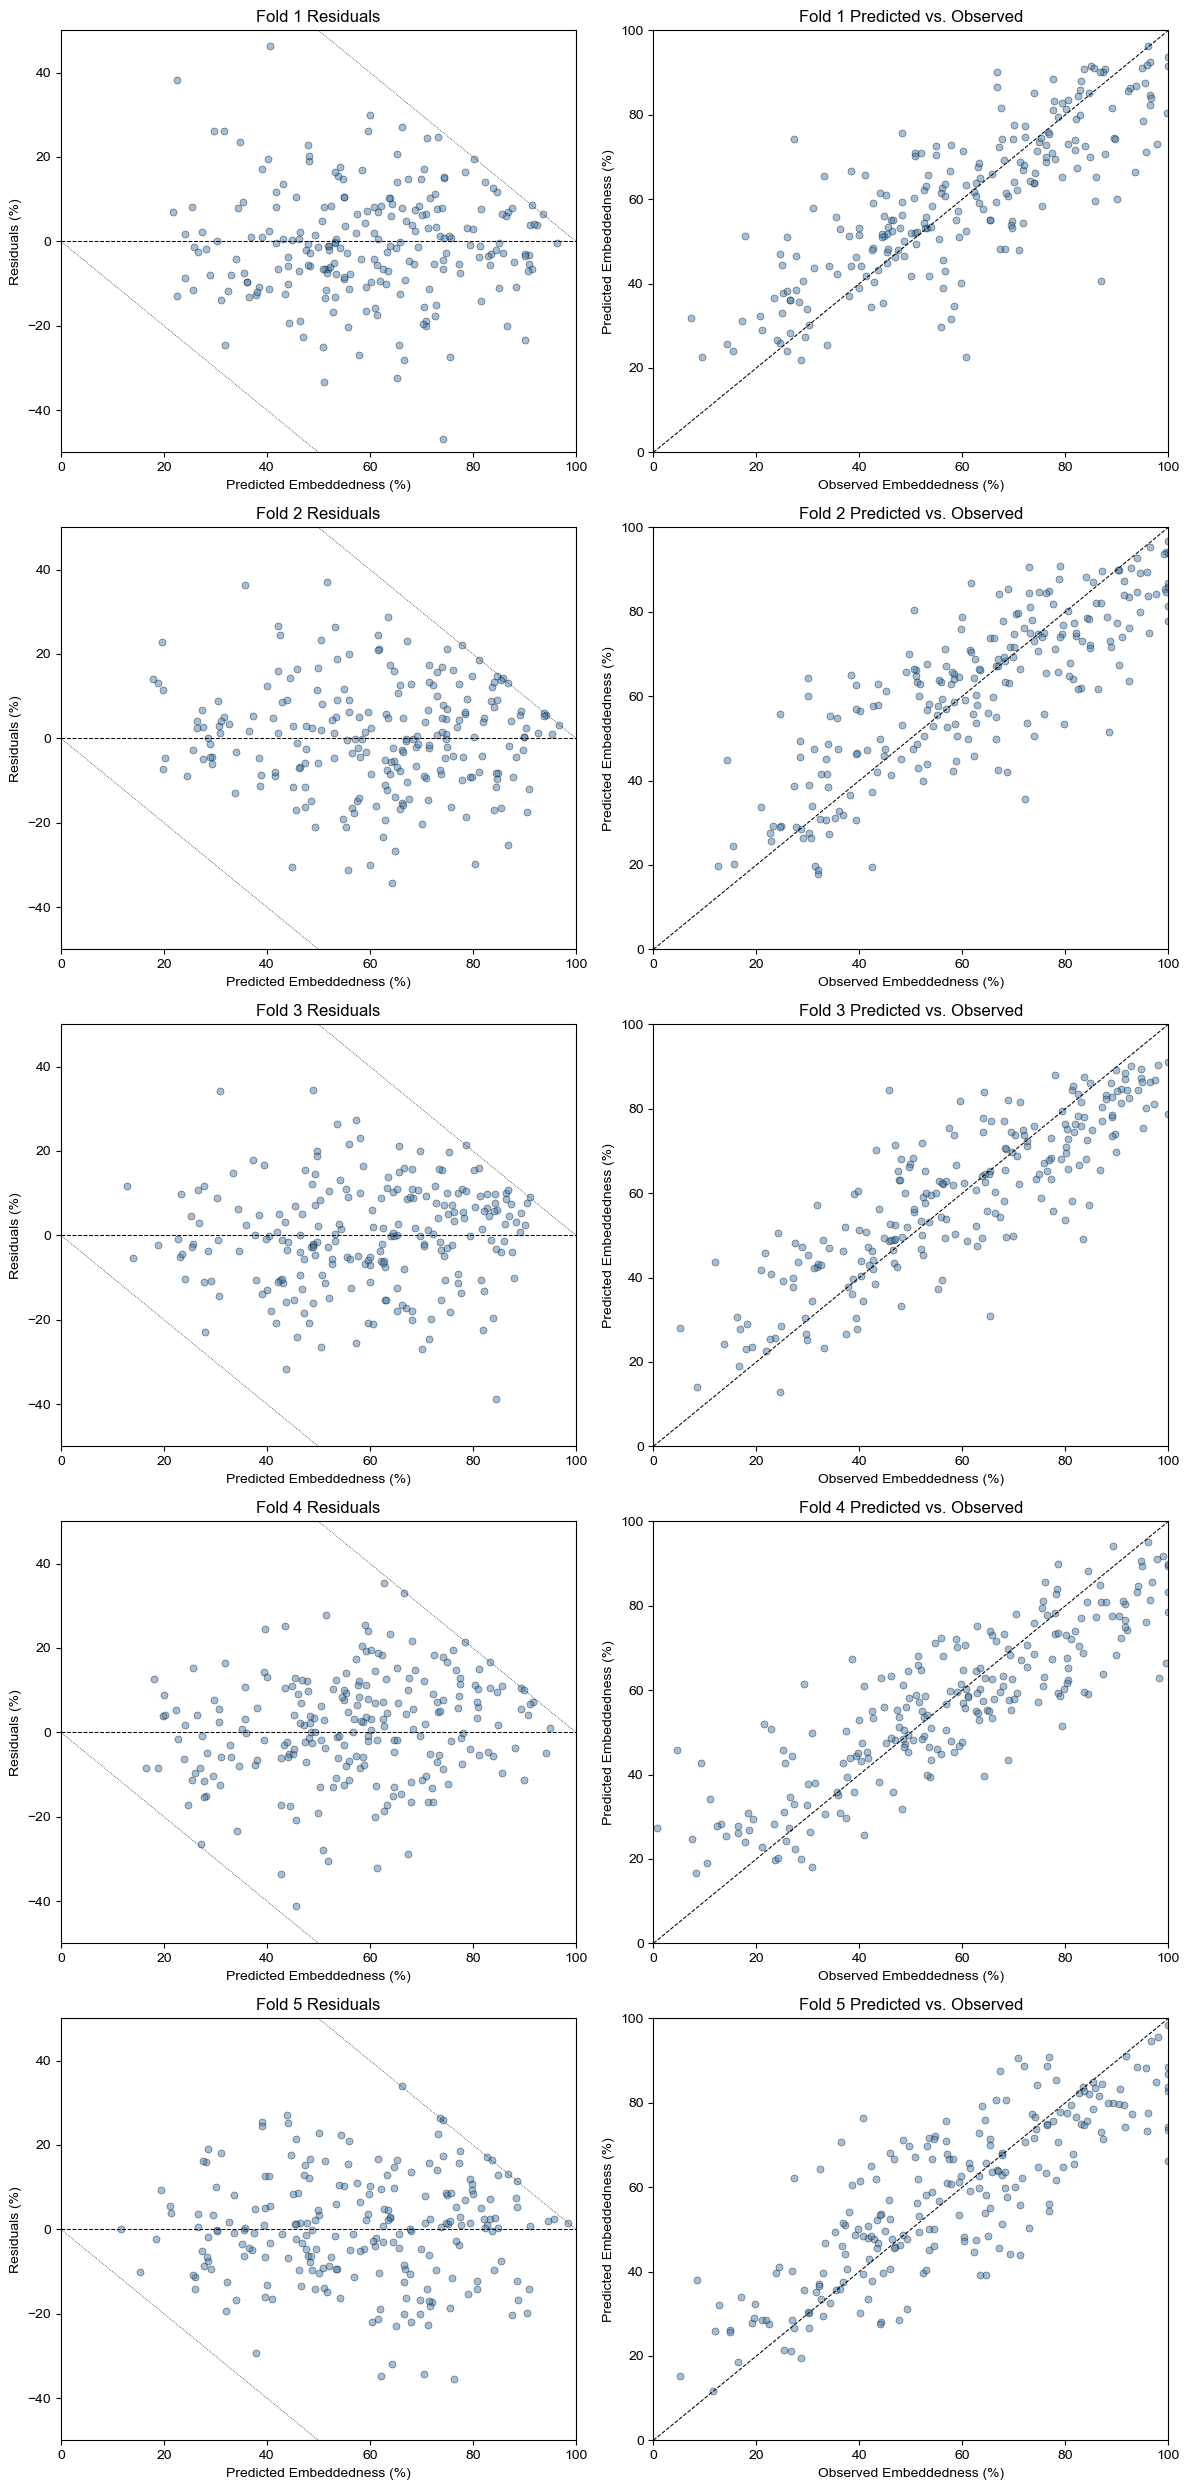

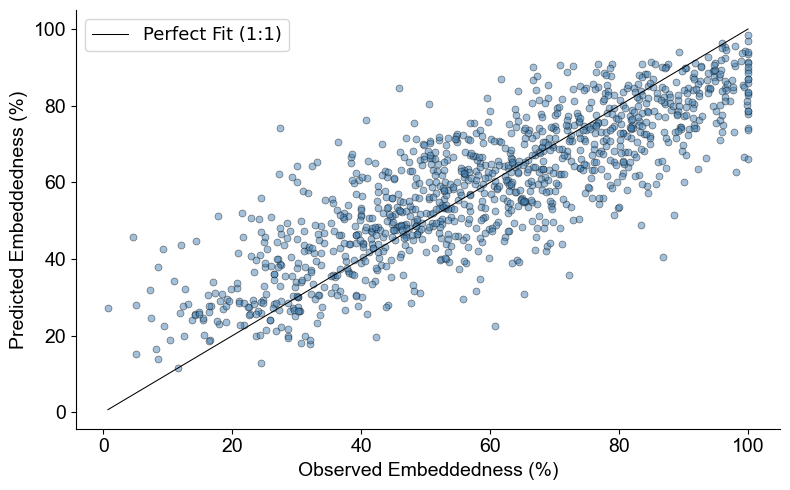

The maximum residual is 46.8454 % embeddedness.
The median residual is 8.2213 % embeddedness.
The minimum residual is 0.0001 % embeddedness.


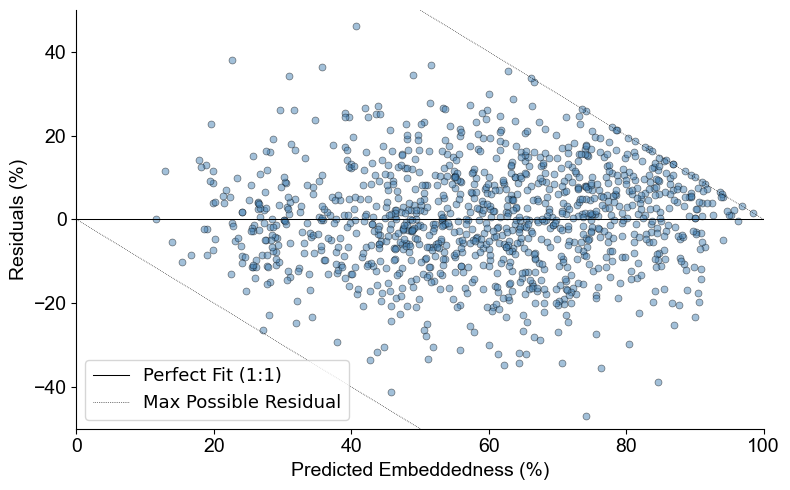

89.0778871978514% of residuals are above 20%


In [22]:
# Use kfold metric function
metric_df, gbr_rmse, gbr_mae, gbr_r2 = kfold_model_metrics(
    model_name="GBR",
    model_builder=lambda: GradientBoostingRegressor(random_state=42, **gbr_best_params),
    X=x_scld,
    Y=y,   
    cv=5,
    coords=coords_df,
    save_path_figures=os.path.join(BASE_DIR, "virginia_streamstats", "results", "figures"),
    save_path_csv=os.path.join(BASE_DIR, "virginia_streamstats", "results")
)

In [ ]:
# Print metric df
print(metric_df)

##### Optuna Plotting for Succesful Algorithm

In [ ]:
# Define best trials from Optuna study
best_trial = gbr_study.best_trial
best_params = best_trial.params  # Best hyperparameter combination
best_value = best_trial.value  # Best RMSE value
best_trial_number = best_trial.number

# Find position in the dataset
best_x = trial_numbers[trial_numbers == best_trial_number].values[0]
best_y = best_value

In [ ]:
# Extract trial numbers and objective values
trials = gbr_study.trials_dataframe()
trials = trials[trials.state == "COMPLETE"]
trial_numbers = trials.number
objective_values = trials.value

# Find best objective value over time
best_values = np.minimum.accumulate(objective_values)

# Plot objective value vs trial num
fig, ax = plt.subplots(figsize=(6, 4))

# Best value dotted line
ax.plot(trial_numbers, best_values, linestyle="dotted", color="black", linewidth=1, label="Best Value", zorder=2)

# Scatter plot for trials
sc = ax.scatter(
    trial_numbers, objective_values,
    color='steelblue', edgecolors='black', facecolors='steelblue', s=25,
    linewidths=0.5, alpha=0.7, label="Trial Objective Values",
    zorder=3
)
# Highlight the best trial
ax.scatter(best_x, best_y, color="white", edgecolors="black", s=150, marker="*", linewidths=1.5, label="Best Trial")

# Customizing aesthetics
ax.set_xlabel("Trial", fontsize=12, fontname="Arial", color="black")
ax.set_ylabel("Negative RMSE", fontsize=12, fontname="Arial", color="black")
ax.set_title("Optimization History of GBR", fontsize=14, fontname="Arial", color="black")

# Show legend
ax.legend(frameon=False, loc="best")
plt.tight_layout()

# Save for paper
opt_hist_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "figures", "va_optimization_history.png")
plt.savefig(opt_hist_path, dpi = 300)

# Display plot
plt.show()

In [ ]:
# Get hyperparameter importance
importance = optuna.importance.get_param_importances(gbr_study, random_state=42)
params = list(importance.keys())
values = list(importance.values())

# Sort by importance (descending)
params, values = zip(*sorted(zip(params, values), key=lambda x: x[1], reverse=False))

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

# Horizontal bar plot
bars = ax.barh(params, values, color="steelblue", edgecolor="black", linewidth=0.7, alpha=0.7)

# Customizing aesthetics
ax.set_facecolor("white")
ax.set_xlabel("Importance", fontsize=12, fontname="Arial", color="black")
ax.set_ylabel("Hyperparameter", fontsize=12, fontname="Arial", color="black")
ax.set_title("Hyperparameter Importance for GBR", fontsize=14, fontname="Arial", color="black")

# Show exact importance values on bars
for bar, value in zip(bars, values):
    ax.text(
        bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}", ha="left", va="center", fontsize=10, fontname="Arial", color="black"
    )
plt.tight_layout()

# Save for paper
opt_imp_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "figures", "va_optimization_importance.png")
plt.savefig(opt_imp_path, dpi = 300)

# Show the plot
plt.show()

In [ ]:
# Find best trial's hyperparameters (top importances)
best_trial = gbr_study.best_trial
best_x = best_trial.params["learning_rate"]
best_y = best_trial.params["n_estimators"]
best_value = best_trial.value  # Best RMSE

In [ ]:
# Select hyperparameters to visualize
param_x_col = "params_learning_rate"
param_y_col = "params_n_estimators"

# Define x and y values
x = trials[param_x_col]
y = trials[param_y_col]
z = trials["value"]  # Objective function value

# Create a figure
fig, ax = plt.subplots(figsize=(6, 4))

# Create a grid for contouring
grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate the objective values for contour plotting
grid_z = griddata((x, y), z, (grid_x, grid_y), method="linear")

# Plot filled contours
contour = ax.contourf(grid_x, grid_y, grid_z, cmap="Blues", alpha=0.7)
contour_lines = ax.contour(grid_x, grid_y, grid_z, colors="black", linewidths=0.5)

# Add color bar
cbar = plt.colorbar(contour)
cbar.set_label("Negative RMSE", fontsize=12, fontname="Arial", color="black")

# Scatter plot of actual trials
ax.scatter(x, y, color="steelblue", edgecolors="black", s=25, linewidths=0.5, alpha=0.7, label="Trials")

# Highlight the best trial
ax.scatter(best_x, best_y, color="white", edgecolors="black", s=150, marker="*", linewidths=1.5, label="Best Trial")

# Customizing aesthetics
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("Learning Rate", fontsize=12, fontname="Arial", color="black")
ax.set_ylabel("Number of Estimators", fontsize=12, fontname="Arial", color="black")
ax.set_title("Contour Plot of Learning Rate vs N Estimators", fontsize=14, fontname="Arial", color="black")

# Show legend
ax.legend(frameon=False)

# Save for paper
opt_contour_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "figures", "va_optimization_countour_plot.png")
plt.savefig(opt_contour_path, dpi = 300)

# Show the plot
plt.show()

#### Model 3. Random Forest Regression

In [ ]:
# Define the Optuna objective function
def rf_objective(trial):
    # Define search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step = 50),  
        "max_depth": trial.suggest_int("max_depth", 10, 50, step = 5),  
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),  
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),  
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]), 
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

    # Create RF model
    model = RandomForestRegressor(random_state = 42, **params, n_jobs = -1)

    # Perform cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, 
                             x_train_scld, 
                             y_train, 
                             cv = kf, 
                             scoring = "neg_root_mean_squared_error", 
                             n_jobs = -1)

    # Return RMSE
    return np.mean(-scores)  

# Define study
rf_study = optuna.create_study(direction = "minimize", study_name = "RF_Optimization")

# Run optimization
rf_study.optimize(rf_objective, n_trials = 50, n_jobs = -1)

# Print best parameters
print("Best hyperparameters:", rf_study.best_params)

# Extract best hyperparameters
rf_best_params = rf_study.best_params

# Train best model with optimized hyperparameters
rf_model = RandomForestRegressor(random_state = 42, **rf_best_params, n_jobs = -1)

# Fit model on training data
rf_model.fit(x_train_scld, y_train)

In [ ]:
# Use kfold metric function
metric_df, rf_rmse, rf_mae, rf_r2 = kfold_model_metrics(
    model_name="RF",
    model_builder=lambda: RandomForestRegressor(
        random_state=42,
        **rf_best_params,
        n_jobs=-1
    ),
    X=x_scld,
    Y=y 
)

In [ ]:
# Print metric df
print(metric_df)

#### Model 4. XGBoost

In [ ]:
# Define the objective function for Optuna
def xgb_objective(trial):
    # Define search  space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.0005, 0.05, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "subsample": trial.suggest_float("subsample", 0.4, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 0.1), 
        "reg_lambda": trial.suggest_float("reg_lambda", 0.8, 1.5),  
        "gamma": trial.suggest_float("gamma", 0, 5),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.8, 1.2),  
    }
    
    # Create model
    model = xgb.XGBRegressor(
        **params,
        random_state = 42,
        tree_method = "hist",
        eval_metric = "rmse",
        n_jobs = -1
    )
    
    # Perform CV
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, 
                             x_train_scld, 
                             y_train, 
                             cv = kf, 
                             scoring = "neg_root_mean_squared_error")
    
    return np.mean(-scores) # Minimize RMSE

# Create Optuna study
xgb_study = optuna.create_study(direction = "minimize", study_name = "XGB_Optimization")

# Run optimization
xgb_study.optimize(xgb_objective, n_trials = 50, n_jobs = -1)

# Print best parameters
print("Best hyperparameters:", xgb_study.best_params)
print("Best RMSE:", xgb_study.best_value)
                            
# Extract best hyperparameters
xgb_best_params = xgb_study.best_params

# Train best model
xgb_model = xgb.XGBRegressor(
    **xgb_best_params,
    random_state = 42,
    tree_method = "hist",
    eval_metric = "rmse"
)

# Fit model on training data
xgb_model.fit(x_train_scld, y_train)

In [ ]:
# Use kfold metric function
metric_df, xgb_rmse, xgb_mae, xgb_r2 = kfold_model_metrics(
    model_name="XGBoost",
    model_builder=lambda: xgb.XGBRegressor(
        **xgb_best_params,
        random_state=42,
        tree_method="hist",
        eval_metric="rmse"
    ),
    X=x_scld,
    Y=y
)

In [ ]:
# Print metric df
print(metric_df)

## Step 4. Model Comparison

In [ ]:
# Display metrics dataframe
metric_df

In [ ]:
# Set figure size
plt.figure(figsize = (20,20))

# Create a subplot for each metric
metrics = ['CV RMSE', 'CV MAE', 'CV R2']
num_met = len(metrics)

# Create a subplot for each metric
fig, axes = plt.subplots(1, num_met, figsize = (20, 5), sharey = False)

for i, met in enumerate(metrics):
    sns.barplot(x = 'Model', 
                y = met, 
                data = metric_df, 
                ax = axes[i], 
                hue = metric_df.index, 
                palette='tab20', 
                legend = False)
    axes[i].set_title(f'Model Comparison - {met}')
    axes[i].set_ylabel(met)
    axes[i].set_xlabel('Model')
    
# Plot results
plt.show()

From the above results, we can see that the **GBR  Model is the best performer.** We'll save this and move on to evaluation.

## Step 5. Export Model & Results

Below is manual training of the model in case the user returns to the notebook and wants to extract results/plots for the GBR model only.

In [14]:
# MANUAL TRAINING
gbr_best_params = {
    "n_estimators": 300,
    "learning_rate": 0.01388,
    "max_depth": 8,
    "min_samples_split": 8,
    "min_samples_leaf": 3,
    "subsample": 0.80921,
    "max_features": "log2"
}

# Train best model with optimized hyperparameters
gbr_model = GradientBoostingRegressor(random_state = 42, **gbr_best_params)

# Fit model on full training data
gbr_model.fit(x_train_scld, y_train)

GradientBoostingRegressor(learning_rate=0.01388, max_depth=8,
                          max_features='log2', min_samples_leaf=3,
                          min_samples_split=8, n_estimators=300,
                          random_state=42, subsample=0.80921)

In [ ]:
# Export metric dataframe (model comparison visualization)
metric_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "vadeq_strmsts_models_metrics.xlsx")
metric_df.to_excel(metric_path)

In [1]:
# Save the trained GBR model and train_test_split for later use
mdl_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "trained_gbr_model.pkl")
train_test_path = os.path.join(BASE_DIR, "virginia_streamstats", "results", "gbr_train_test_sets.pkl")

# Save sets/model
joblib.dump(gbr_model, mdl_path)
print(f'GBR model saved as {mdl_path}')
joblib.dump((x_train_scld, x_test_scld, y_train, y_test), train_test_path)
print(f'Training and testing sets saved as {train_test_path}')

NameError: name 'os' is not defined